|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 0:</h2>|<h1>From a Program to a Model<h1>|
|<h2>Section:</h2>|<h1>How to measure<h1>|
|<h2>Lecture:</h2>|<h1><b>A stopwatch that lies<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

# A stopwatch that lies

The rest of this course measures the GPU, again and again. Before you trust
a single number, you must know three ways that a measurement of a GPU goes
wrong. Each one gave a wrong number to people with years of experience.

Every move of the method in `docs/METHOD.md` depends on a measurement that
you can trust. This notebook is about that trust. Each section below asks you
to predict first.

In [1]:
# find the repo root. The directory you start from does not matter.
import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import cudalib

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# 1. The GPU works from a queue

When Python calls a GPU function, the call puts the work in a queue and
returns at once. The GPU does the work later. This is **asynchronous**
execution. It is the same queue that hid the Python time in assumption 5
of section `0_map`.

Here is a stopwatch around 50 multiplications of two 4096 x 4096 matrices.
The first version stops the stopwatch when Python returns. The second version
waits for the GPU first, with `torch.cuda.synchronize()`.

Predict: the time with the wait, divided by the time without it.

In [2]:
PREDICTED_RATIO = None      # your number

In [3]:
left_matrix = torch.randn(4096, 4096, device='cuda', dtype=torch.bfloat16)
right_matrix = torch.randn(4096, 4096, device='cuda', dtype=torch.bfloat16)
for _ in range(3):                                   # warm up: section 2 explains why
    left_matrix @ right_matrix
torch.cuda.synchronize()

start = time.perf_counter()
for _ in range(50):
    left_matrix @ right_matrix
no_wait = time.perf_counter() - start                # Python returned. The GPU did not finish.
torch.cuda.synchronize()

torch.cuda.synchronize()
start = time.perf_counter()
for _ in range(50):
    left_matrix @ right_matrix
torch.cuda.synchronize()                             # wait for the GPU
with_wait = time.perf_counter() - start

print(f'without the wait: {no_wait*1e3:8.2f} ms')
print(f'with the wait:    {with_wait*1e3:8.2f} ms')
print(f'-> ratio {with_wait/no_wait:.0f}x.  You predicted {PREDICTED_RATIO}.')

without the wait:     0.29 ms
with the wait:      129.48 ms
-> ratio 452x.  You predicted None.


The first number measures how fast Python puts work in the queue. It says
nothing about the GPU. Code that looks 10 or 100 times faster after a change
often has only lost its wait.

**Rule 1.** Wait for the GPU before you stop the stopwatch: call
`torch.cuda.synchronize()`, or use CUDA events, which time the GPU itself.

# 2. The first call is different

The first call of a GPU function with a new shape does extra work: it
chooses an algorithm, allocates memory, and sometimes compiles code.

Predict: the time of the first call of a new shape, divided by the time of a
later call.

In [4]:
PREDICTED_FIRST = None      # your number

In [5]:
def one_call_ms(function):
    torch.cuda.synchronize()
    start = time.perf_counter()
    function()
    torch.cuda.synchronize()
    return (time.perf_counter() - start) * 1e3

left_new_shape = torch.randn(3001, 2999, device='cuda', dtype=torch.bfloat16)     # a shape not used before
right_new_shape = torch.randn(2999, 3003, device='cuda', dtype=torch.bfloat16)
first = one_call_ms(lambda: left_new_shape @ right_new_shape)
later = np.median([one_call_ms(lambda: left_new_shape @ right_new_shape) for _ in range(20)])
print(f'first call: {first:7.2f} ms')
print(f'later call: {later:7.2f} ms')
print(f'-> ratio {first/later:.1f}x.  You predicted {PREDICTED_FIRST}.')

first call:    1.62 ms
later call:    1.23 ms
-> ratio 1.3x.  You predicted None.


The ratio changes from card to card and from run to run. It is never 1 by
design. If your timing includes the first call, you time the setup, not the
work.

**Rule 2.** Warm up: call the function a few times before you start the
stopwatch.

# 3. One number is not a measurement

Run the same work 300 times, and you get 300 different times. Other
programs, the temperature of the chip, and its clock speed all move them. A
laptop GPU raises its clock when it is cool, and lowers it when it is hot.

Predict: the slowest 1% of the runs (the **p99**), divided by the middle run
(the **median**).

In [6]:
PREDICTED_TAIL = None      # your number

    min:   268.2 us
 median:   316.4 us
   mean:   344.6 us
    p99:   431.8 us
-> p99 / median = 1.36.  You predicted None.


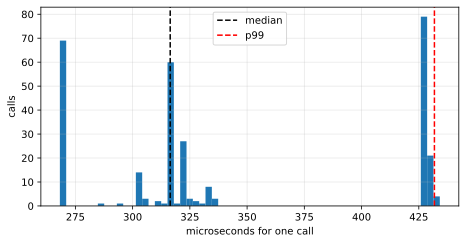

In [7]:
square_matrix = torch.randn(2048, 2048, device='cuda', dtype=torch.bfloat16)
for _ in range(10):
    square_matrix @ square_matrix
times = []
for _ in range(300):
    start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    start.record()
    square_matrix @ square_matrix
    end.record()
    end.synchronize()
    times.append(start.elapsed_time(end))
times = np.array(times)

for name, value in [('min', times.min()), ('median', np.median(times)),
                    ('mean', times.mean()), ('p99', np.percentile(times, 99))]:
    print(f'{name:>7}: {value*1e3:7.1f} us')
print(f'-> p99 / median = {np.percentile(times, 99)/np.median(times):.2f}.  You predicted {PREDICTED_TAIL}.')

plt.figure(figsize=(7.5, 3.6))
plt.hist(times * 1e3, bins=60)
plt.axvline(np.median(times) * 1e3, color='k', ls='--', label='median')
plt.axvline(np.percentile(times, 99) * 1e3, color='r', ls='--', label='p99')
plt.xlabel('microseconds for one call')
plt.ylabel('calls')
plt.legend()
plt.grid(alpha=.3)
plt.show()

Each summary answers a different question. Choose the one that matches your
question:

| The question | The number | Why |
|---|---|---|
| What can the hardware do? Which of two kernels is faster? | the **min**, or the best of some rounds | The fastest run is the one that the noise changed least. |
| What does a typical call cost? | the **median** | Half the runs are faster and half are slower. One slow run cannot move it. |
| What do the unluckiest users feel? | the **p99**, or the p99.9 | A service is judged by its slow requests. Stage 16 measures them. |
| (Almost never) | the mean | A few slow runs pull it up. It describes no real run. |

**Rule 3.** Repeat the measurement, and report the summary that answers your
question. Compare two versions on the same machine, one after the other, and
more than once. `cudalib.compare_ms` does this.

### What to remember from this notebook

1. **Wait for the GPU** before you stop the stopwatch.
2. **Warm up** before you start it.
3. **Repeat**, and choose the min, the median or the p99 by your question.

`cudalib.bench_ms`, which the rest of the course uses, does all three. Now you
know what it does, and why. When a number in this course surprises you,
check these three rules before you check anything else.